In [2]:
import pandas as pd
import re
from functools import reduce
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from tensorflow.keras.models import load_model
import seaborn as sns
import math

### Results to plot Figure 2A

In [79]:
pseudo_bulk_cv=pd.read_csv("/data/kumarr17/single_cell_cross_tissue_ML_analysis/model_cv_accuracy/sc_epi_CV.csv",index_col='Unnamed: 0')
tcga_bulk_cv=pd.read_csv("/data/kumarr17/single_cell_cross_tissue_ML_analysis/model_cv_accuracy/tcga_epi_CV.csv",index_col='Unnamed: 0')
df_merge1=pd.merge(tcga_bulk_cv,pseudo_bulk_cv,on='cytokine')
df_merge1.columns=['cv_tcga_epi','cytokine','cv_sc_epi']

In [80]:
pseudo_bulk_cv=pd.read_csv("/data/kumarr17/single_cell_cross_tissue_ML_analysis/model_cv_accuracy/pseudo_bulk_CV.csv",index_col='Unnamed: 0')
tcga_bulk_cv=pd.read_csv("/data/kumarr17/single_cell_cross_tissue_ML_analysis/model_cv_accuracy/tcga_bulk_CV.csv",index_col='Unnamed: 0')
df_merge=pd.merge(tcga_bulk_cv,pseudo_bulk_cv,on='cytokine')
df_merge.columns=['cv_tcga_bulk','cytokine','cv_sc_pseudobulk']

In [81]:
df_merge_bulk_pseudo_bulk=pd.merge(df_merge,df_merge1,on='cytokine')

### Figure 2A :Comparing model TCGA bulk and single cells

/tmp/ipykernel_1428991/4133008853.py:83: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


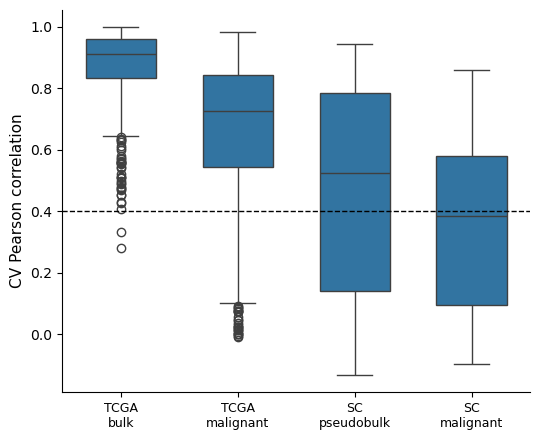

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Prepare data
# ============================================================

df = df_merge_bulk_pseudo_bulk

df_long = df[
    [
        "cv_tcga_bulk",
        "cv_tcga_epi",
        "cv_sc_pseudobulk",
        "cv_sc_epi"
    ]
].melt(
    var_name="Model",
    value_name="CV_accuracy"
)

# Cleaner model names
df_long["Model"] = df_long["Model"].replace({
    "cv_tcga_bulk": "TCGA bulk",
    "cv_tcga_epi": "TCGA epithelial",
    "cv_sc_pseudobulk": "SC pseudobulk",
    "cv_sc_epi": "SC epithelial"
})

# Explicit order
order = [
    "TCGA bulk",
    "TCGA epithelial",
    "SC pseudobulk",
    "SC epithelial"
]


# ============================================================
# 2. Create manuscript figure
# ============================================================

fig, ax = plt.subplots(figsize=(5.5, 4.5))

sns.boxplot(
    data=df_long,
    x="Model",
    y="CV_accuracy",
    order=order,
    showfliers=True,
    width=0.6,
    linewidth=1,
    ax=ax
)




# ============================================================
# 3. Reference line
# ============================================================

ax.axhline(
    y=0.4,
    color="black",
    linestyle="--",
    linewidth=1
)


# ============================================================
# 4. Axis formatting
# ============================================================

ax.set_xlabel("")

ax.set_ylabel(
    "CV Pearson correlation",
    fontsize=11
)

ax.set_xticklabels(
    [
        "TCGA\nbulk",
        "TCGA\nmalignant",
        "SC\npseudobulk",
        "SC\nmalignant"
    ],
    fontsize=9
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# ============================================================
# 5. Manuscript formatting
# ============================================================

# Usually omit title for manuscript panels
# ax.set_title("Cross-validation performance")

sns.despine(ax=ax)

ax.grid(False)

plt.tight_layout()


# ============================================================
# 6. Save as vector SVG
# ============================================================

#fig.savefig(
#    "/data/kumarr17/cytokine_figure_directory/CV_accuracy_TCGA_vs_single_cell_models.svg",
#    format="svg",
#    bbox_inches="tight",
#    pad_inches=0.05
#)

plt.show()